Convolutional Neural Network (CNN) — CIFAR-10 Image Classification

In [5]:
# CELL 1 — Imports
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

torch.manual_seed(42)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cpu


In [6]:
# CELL 2 — Load CIFAR-10 dataset
transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])
transform_test = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))
])

train_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=True, download=True, transform=transform_train
)
test_dataset = torchvision.datasets.CIFAR10(
    root="./data", train=False, download=True, transform=transform_test
)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=256, shuffle=False, num_workers=2)

classes = ("plane", "car", "bird", "cat", "deer", "dog", "frog", "horse", "ship", "truck")
print(f"Train samples: {len(train_dataset)} | Test samples: {len(test_dataset)}")

Train samples: 50000 | Test samples: 10000


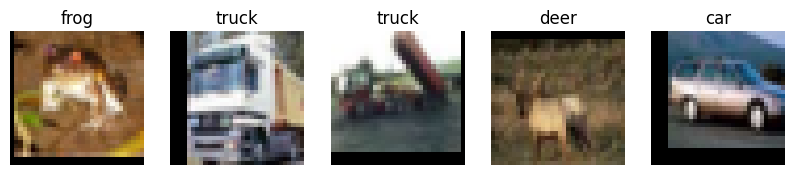

In [7]:
# CELL 3 — Visualize a few samples
def unnormalize(img):
    mean = torch.tensor((0.4914, 0.4822, 0.4465)).view(3, 1, 1)
    std = torch.tensor((0.2470, 0.2435, 0.2616)).view(3, 1, 1)
    return img * std + mean

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    img, label = train_dataset[i]
    axes[i].imshow(unnormalize(img).permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(classes[label])
    axes[i].axis("off")
plt.show()

In [8]:
# CELL 4 — Model definition
class CIFAR10CNN(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv_stack = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.Conv2d(32, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 32 -> 16

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 16 -> 8

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2),  # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.conv_stack(x)
        return self.classifier(x)

model = CIFAR10CNN().to(device)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)
print(model)

CIFAR10CNN(
  (conv_stack): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (2): ReLU()
    (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (5): ReLU()
    (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (9): ReLU()
    (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (12): ReLU()
    (13): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (14): Conv2d(64, 128,

In [9]:
# CELL 5 — Training loop
epochs = 10
for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_loss = running_loss / len(train_loader)
    train_acc = 100 * correct / total
    print(f"Epoch {epoch+1}/{epochs} — Loss: {avg_loss:.4f} | Train Acc: {train_acc:.2f}%")

Epoch 1/10 — Loss: 1.5081 | Train Acc: 44.47%
Epoch 2/10 — Loss: 1.0655 | Train Acc: 61.86%
Epoch 3/10 — Loss: 0.9053 | Train Acc: 67.94%
Epoch 4/10 — Loss: 0.8131 | Train Acc: 71.46%
Epoch 5/10 — Loss: 0.7538 | Train Acc: 73.63%
Epoch 6/10 — Loss: 0.7088 | Train Acc: 75.18%
Epoch 7/10 — Loss: 0.6655 | Train Acc: 76.98%
Epoch 8/10 — Loss: 0.6343 | Train Acc: 78.06%
Epoch 9/10 — Loss: 0.6134 | Train Acc: 79.05%
Epoch 10/10 — Loss: 0.5819 | Train Acc: 80.14%


In [10]:
# CELL 6 — Evaluation
model.eval()
correct = 0
total = 0
class_correct = [0] * 10
class_total = [0] * 10

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)
        logits = model(images)
        preds = torch.argmax(logits, dim=1)

        correct += (preds == labels).sum().item()
        total += labels.size(0)

        for label, pred in zip(labels, preds):
            class_total[label] += 1
            if label == pred:
                class_correct[label] += 1

print(f"Overall Test Accuracy: {100 * correct / total:.2f}%")
print("\nPer-class accuracy:")
for i, name in enumerate(classes):
    acc = 100 * class_correct[i] / class_total[i]
    print(f"  {name}: {acc:.2f}%")

Overall Test Accuracy: 80.99%

Per-class accuracy:
  plane: 79.30%
  car: 84.50%
  bird: 74.30%
  cat: 58.50%
  deer: 85.30%
  dog: 75.80%
  frog: 79.90%
  horse: 90.90%
  ship: 89.90%
  truck: 91.50%


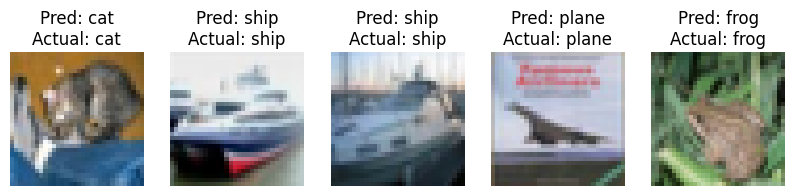

: 

In [ ]:
# CELL 7 — Visualize predictions
model.eval()
images, labels = next(iter(test_loader))
images, labels = images.to(device), labels.to(device)

with torch.no_grad():
    logits = model(images[:5])
    preds = torch.argmax(logits, dim=1)

fig, axes = plt.subplots(1, 5, figsize=(10, 2))
for i in range(5):
    axes[i].imshow(unnormalize(images[i].cpu()).permute(1, 2, 0).clamp(0, 1))
    axes[i].set_title(f"Pred: {classes[preds[i]]}\nActual: {classes[labels[i]]}")
    axes[i].axis("off")
plt.show()